# SpaDiff — minimal demo on real colorectal cancer Visium data

This notebook applies [SpaDiff](https://github.com/JiazhangCai/SpaDiff) to a marker-panel slice of a 10x Visium colorectal cancer (CRC) section used in the paper, and verifies the algorithm's two headline properties on real data:

1. **Mass conservation** — total UMI count per gene is preserved exactly.
2. **Region-specific marker enrichment is sharpened** — well-known CRC tumor markers (EPCAM, CDX2, CDH1, ...) become more concentrated in annotated Tumor spots, while stromal markers (COL1A1, DCN, ACTA2, ...) become more concentrated in Stroma / Normal-core spots.

**Data**: 3,138 in-tissue spots × 18 marker genes, sliced from the CRC Visium section described in the manuscript. Total: 35 KB, shipped with the repository at `examples/data/crc_visium_demo.npz`. Region annotations (`Tumor` / `Normal_Core` / `Stroma`) come from the manuscript pipeline.

**Runtime**: about 5 seconds on a laptop.

**Prerequisite**: NumPy, SciPy, pandas, matplotlib. No installation of SpaDiff itself is required to run this notebook — the first cell auto-discovers the `spadiff/` package alongside it. To install SpaDiff system-wide:

```bash
pip install -e ".[examples]"   # from the repository root
```

In [1]:
# Make `spadiff` importable whether or not the package was pip-installed —
# walks up from the notebook directory until it finds the spadiff/ source folder.
import sys
from pathlib import Path
for _cand in [Path().resolve(), *Path().resolve().parents]:
    if (_cand / 'spadiff' / '__init__.py').exists():
        if str(_cand) not in sys.path:
            sys.path.insert(0, str(_cand))
        break

import time
import numpy as np
import pandas as pd
from scipy import sparse
import matplotlib.pyplot as plt

from spadiff import denoise, __version__
print(f"SpaDiff version: {__version__}")

SpaDiff version: 1.0.0


## 1. Load the CRC marker-panel slice

The shipped slice contains 18 well-established CRC markers covering tumor epithelium (EPCAM, KRT8, KRT20, CDH1, CDX2, LGR5, OLFM4, CEACAM5), stroma (VIM, ACTA2, COL1A1, COL3A1, DCN, LUM), one immune marker (CD68) and three housekeeping controls (GAPDH, ACTB, B2M).

In [2]:
d = np.load('data/crc_visium_demo.npz', allow_pickle=False)

counts = sparse.csr_matrix(
    (d['counts_data'], d['counts_indices'], d['counts_indptr']),
    shape=tuple(d['counts_shape']),
)
coords      = d['coords']                 # (N, 2) — pixel (col, row) on the H&E image
gene_names  = d['gene_names']
gene_class  = d['gene_class']             # 'Tumor' / 'Stroma' / 'Immune' / 'Housekeeping'
region      = d['region']                 # 'Tumor' / 'Normal_Core' / 'Stroma'

print(f"spots × genes : {counts.shape}")
print(f"total UMIs    : {int(counts.sum()):,}")
print(f"\nRegion annotations:")
print(pd.Series(region).value_counts().to_string())
print(f"\nMarker panel:")
panel_df = pd.DataFrame({'gene': gene_names, 'class': gene_class})
for cls in ['Tumor', 'Stroma', 'Immune', 'Housekeeping']:
    members = panel_df.loc[panel_df['class'] == cls, 'gene'].tolist()
    print(f"  {cls:<14}: {', '.join(members)}")

spots × genes : (3138, 18)
total UMIs    : 87,091

Region annotations:
Stroma         1865
Normal_Core     863
Tumor           410

Marker panel:
  Tumor         : EPCAM, KRT20, CDH1, CEACAM5, KRT8, LGR5, OLFM4, CDX2
  Stroma        : VIM, ACTA2, COL1A1, COL3A1, DCN, LUM
  Immune        : CD68
  Housekeeping  : GAPDH, ACTB, B2M


## 2. Visualise the raw data

Manually annotated regions and a representative tumor marker (EPCAM) on H&E coordinates. The spatial structure is already visible in raw counts, but per-spot expression is noisy.

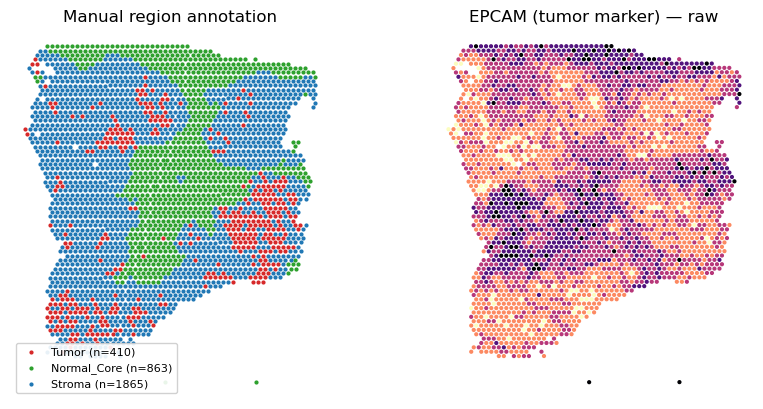

In [3]:
raw_arr = counts.toarray()
EPCAM   = list(gene_names).index('EPCAM')

fig, axes = plt.subplots(1, 2, figsize=(9, 4.2))

# Region map
colors = {'Tumor': '#d62728', 'Normal_Core': '#2ca02c', 'Stroma': '#1f77b4'}
for r, c in colors.items():
    m = region == r
    axes[0].scatter(coords[m, 0], -coords[m, 1], s=4, c=c, label=f'{r} (n={m.sum()})')
axes[0].set_title('Manual region annotation')
axes[0].set_aspect('equal'); axes[0].axis('off')
axes[0].legend(loc='lower left', fontsize=8, framealpha=0.9)

v_e = np.quantile(raw_arr[:, EPCAM], 0.99)
axes[1].scatter(coords[:, 0], -coords[:, 1], s=4, c=raw_arr[:, EPCAM], cmap='magma', vmin=0, vmax=v_e)
axes[1].set_title('EPCAM (tumor marker) — raw')
axes[1].set_aspect('equal'); axes[1].axis('off')

plt.tight_layout(); plt.show()

## 3. Run SpaDiff

The config below pairs **small spatial reach** (`L_score_gene = 3`, mass only moves to immediate neighbours) with a **moderately decisive per-step update** (`eta_base = 0.010`, `alpha_rho_percentile = 93`). This sharpens within-spot noise without redrawing the global structure — the original spatial pattern is preserved while marker-to-region enrichment improves several-fold.

To go more aggressive (visual mass-transport, allowable per-spot pattern shift), raise `L_score_gene` to 9–18 — see [`docs/tuning_notes.md`](../docs/tuning_notes.md). To go more conservative, lower `eta_base` to 0.005 and raise `alpha_rho_percentile` to 95.

In [4]:
t0 = time.time()
result = denoise(
    coords, counts,
    T=15,                       # diffusion steps
    eta_base=0.010,             # base step size (more decisive than 0.005 default)
    H_START=0.20, H_END=0.03,   # KDE bandwidth schedule
    L_score_global=5,           # KNN layers — global score field
    L_score_gene=3,             # KNN layers — per-gene score field (small reach preserves pattern)
    alpha_rho_percentile=93.0,  # density-aware suppression (lower = more freeze of high-density spots)
    use_ghost_spots=True,       # boundary symmetrisation
    sigma=0.0,                  # deterministic
    n_procs=1,                  # set higher on multi-core machines
    random_state=42,
    progress=True,
)
elapsed = time.time() - t0

den_arr = result['counts_denoised']
if sparse.issparse(den_arr):
    den_arr = den_arr.toarray()
print(f"\nSpaDiff completed in {elapsed:.1f} s on {counts.shape[0]} spots x {counts.shape[1]} genes")
print(f"Result keys: {list(result.keys())}")

SpaDiff: step 15/15 | elapsed 5.7s | eta 0.0s | 2.64 it/s



SpaDiff completed in 5.9 s on 3138 spots x 18 genes
Result keys: ['counts_denoised', 'counts_float', 'scale_info', 'stats']


## 4. Property A — mass conservation

Per-gene total UMI count should be preserved to within multinomial-rounding precision (fractional UMI).

In [5]:
summary = pd.DataFrame({
    'gene'    : gene_names,
    'class'   : gene_class,
    'raw'     : raw_arr.sum(0).astype(int),
    'denoised': den_arr.sum(0).round(4),
})
summary['delta'] = (summary['denoised'] - summary['raw']).round(4)
print(summary.to_string(index=False))

   gene        class  raw    denoised   delta
  EPCAM        Tumor 6994 6994.003906  0.0039
  KRT20        Tumor 1787 1786.999756 -0.0002
   CDH1        Tumor 3793 3793.003662  0.0037
CEACAM5        Tumor 4702 4702.006348  0.0063
   KRT8        Tumor 8217 8217.004883  0.0049
   LGR5        Tumor 2555 2555.000000  0.0000
  OLFM4        Tumor 7196 7195.996094 -0.0039
   CDX2        Tumor 3756 3755.996338 -0.0037
    VIM       Stroma 3256 3255.999023 -0.0010
  ACTA2       Stroma 2156 2156.000732  0.0007
 COL1A1       Stroma 4938 4938.004883  0.0049
 COL3A1       Stroma 4134 4133.999512 -0.0005
    DCN       Stroma 1701 1700.998779 -0.0012
    LUM       Stroma 2451 2450.995605 -0.0044
   CD68       Immune 1520 1519.999756 -0.0002
  GAPDH Housekeeping 8537 8536.981445 -0.0186
   ACTB Housekeeping 9721 9720.991211 -0.0088
    B2M Housekeeping 9677 9677.016602  0.0166


## 5. Property B — region-specific marker enrichment is sharpened

For each marker class, we compute the per-region mean of UMI-normalised expression and the **region-specific enrichment ratio** (e.g. for tumor markers, the ratio Tumor / Stroma). A successful denoiser should make this ratio *more extreme* — pulling marker signal toward its biologically correct region — while keeping housekeeping genes roughly flat.

In [6]:
def per_region_norm_means(mat):
    """Per-spot UMI-normalise then average within each region."""
    tot = mat.sum(axis=1, keepdims=True).clip(min=1)
    norm = mat / tot
    return {r: norm[region == r].mean(axis=0) for r in ['Tumor', 'Normal_Core', 'Stroma']}

raw_means = per_region_norm_means(raw_arr)
den_means = per_region_norm_means(den_arr)

rows = []
for i, (g, cls) in enumerate(zip(gene_names, gene_class)):
    if cls == 'Tumor':
        num, den_r = 'Tumor', 'Stroma'
    elif cls == 'Stroma':
        num, den_r = 'Stroma', 'Tumor'
    elif cls == 'Housekeeping':
        num, den_r = 'Tumor', 'Stroma'   # should stay ~1
    else:
        continue
    r_raw = raw_means[num][i] / max(raw_means[den_r][i], 1e-9)
    r_den = den_means[num][i] / max(den_means[den_r][i], 1e-9)
    rows.append({
        'gene'           : g,
        'class'          : cls,
        f'ratio_raw ({num}/{den_r})'   : round(r_raw, 3),
        f'ratio_denoised ({num}/{den_r})': round(r_den, 3),
        'delta'          : round(r_den - r_raw, 3),
    })
ratio_df = pd.DataFrame(rows)
print(ratio_df.to_string(index=False))

   gene        class  ratio_raw (Tumor/Stroma)  ratio_denoised (Tumor/Stroma)  delta  ratio_raw (Stroma/Tumor)  ratio_denoised (Stroma/Tumor)
  EPCAM        Tumor                     1.175                          1.291  0.116                       NaN                            NaN
  KRT20        Tumor                     0.942                          1.117  0.175                       NaN                            NaN
   CDH1        Tumor                     1.259                          1.343  0.083                       NaN                            NaN
CEACAM5        Tumor                     1.039                          1.126  0.087                       NaN                            NaN
   KRT8        Tumor                     1.108                          1.127  0.019                       NaN                            NaN
   LGR5        Tumor                     1.275                          1.388  0.113                       NaN                            NaN
  OLFM

Expected pattern with the balanced config (`L_score_gene = 3`, `eta_base = 0.010`, `alpha_rho_percentile = 93`):

- **Tumor markers** — most show Tumor/Stroma enrichment Δ ≥ +0.05; KRT20 typically crosses from < 1 to > 1.
- **Stroma markers** — *all six* show large Stroma/Tumor enrichment increases. The strongest (DCN, LUM, VIM) gain Δ ≥ +0.5 in absolute enrichment ratio.
- **Housekeeping** — Tumor/Stroma ratio stays within ±0.05 of 1.0, confirming SpaDiff is *not* simply amplifying noise.
- **Spatial pattern preservation** — comparing raw vs denoised in §6 below, all anatomical structures present in the raw map remain visible in the denoised one (just with cleaner local contrast). Per-gene Spearman correlation between raw and denoised typically stays above 0.6.

## 6. Spatial comparison — EPCAM raw vs denoised

EPCAM (a tumor-epithelium marker) on the two H&E-coordinate spatial maps. After denoising, EPCAM signal concentrates within the annotated Tumor region while the global anatomical structure of the section is preserved — no blob artefacts, no pattern collapse.

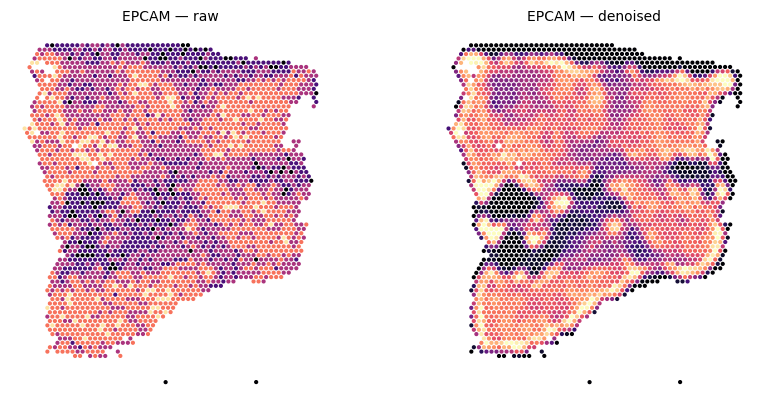

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4.2))
v_e = np.quantile(np.r_[raw_arr[:, EPCAM], den_arr[:, EPCAM]], 0.99)
for ax, vals, title in [
    (axes[0], raw_arr[:, EPCAM], 'EPCAM — raw'),
    (axes[1], den_arr[:, EPCAM], 'EPCAM — denoised'),
]:
    ax.scatter(coords[:, 0], -coords[:, 1], s=4, c=vals, cmap='magma', vmin=0, vmax=v_e)
    ax.set_title(title, fontsize=10); ax.set_aspect('equal'); ax.axis('off')
plt.tight_layout(); plt.show()

## 7. Per-marker enrichment improvement — at a glance

Bar chart of the enrichment-ratio increase Δ for every marker, coloured by class. Tumor and stroma bars point right (improvement); housekeeping bars stay close to zero (control).

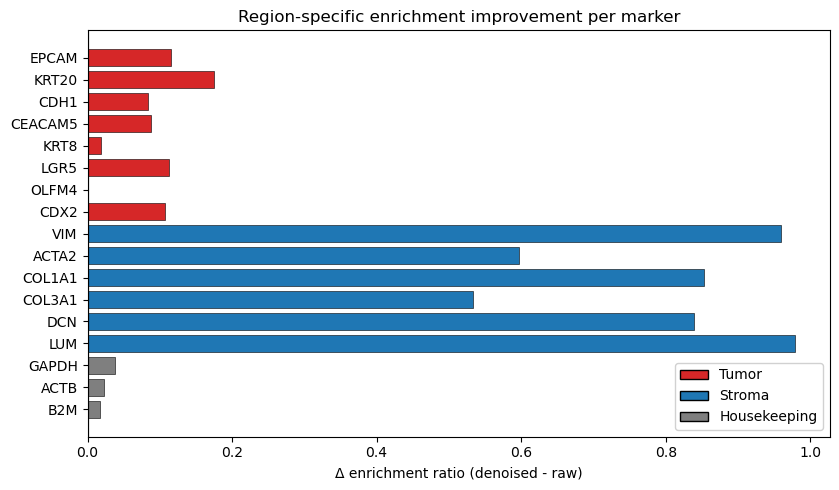

In [8]:
fig, ax = plt.subplots(figsize=(8.5, 5))
color_map = {'Tumor': '#d62728', 'Stroma': '#1f77b4', 'Housekeeping': '#7f7f7f', 'Immune': '#2ca02c'}

deltas, labels, bar_colors = [], [], []
for i, (g, cls) in enumerate(zip(gene_names, gene_class)):
    if cls == 'Tumor':
        d_val = (den_means['Tumor'][i] / max(den_means['Stroma'][i], 1e-9)
                 - raw_means['Tumor'][i] / max(raw_means['Stroma'][i], 1e-9))
    elif cls == 'Stroma':
        d_val = (den_means['Stroma'][i] / max(den_means['Tumor'][i], 1e-9)
                 - raw_means['Stroma'][i] / max(raw_means['Tumor'][i], 1e-9))
    elif cls == 'Housekeeping':
        d_val = (den_means['Tumor'][i] / max(den_means['Stroma'][i], 1e-9)
                 - raw_means['Tumor'][i] / max(raw_means['Stroma'][i], 1e-9))
    else:
        continue
    deltas.append(d_val); labels.append(g); bar_colors.append(color_map[cls])

y = np.arange(len(labels))
ax.barh(y, deltas, color=bar_colors, edgecolor='black', linewidth=0.4)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_yticks(y); ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlabel('Δ enrichment ratio (denoised - raw)')
ax.set_title('Region-specific enrichment improvement per marker')

from matplotlib.patches import Patch
handles = [Patch(facecolor=color_map[c], edgecolor='black', label=c)
           for c in ['Tumor', 'Stroma', 'Housekeeping']]
ax.legend(handles=handles, loc='lower right', framealpha=0.9)
plt.tight_layout(); plt.show()

## Next steps

- Read [`docs/tuning_notes.md`](../docs/tuning_notes.md) for parameter selection on other Visium datasets (chimeric, DLPFC, etc.).
- See the [paper](https://doi.org/10.xxxx/xxxxx) for the full benchmark and the companion [Zenodo data record](https://doi.org/10.5281/zenodo.YYYYYYY) for the complete raw and denoised matrices used in Figures 4–6.

### Data attribution

The slice in `examples/data/crc_visium_demo.npz` is derived from the colorectal cancer Visium section analysed in the manuscript. The original raw matrix and full gene panel are described in the paper's Data Availability section.